In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
def simple_iteration(A: np.ndarray, b: np.ndarray, x0: np.ndarray, x_tr: np.ndarray, tol=1e-10, max_iter=100):
    errors = []
    x = x0.copy()

    I = np.identity(A.shape[0])
    B_iter = I - A
    c_iter = b

    
    for i in range(max_iter):
        x_new = B_iter @ x + c_iter
        
        diff = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(np.linalg.norm(x_new - x_tr, ord=np.inf))

        if diff < tol:
            print(f"сошелся за {i+1} итераций.")
            return x_new, errors

        x = x_new

    print("максимальное количество итераций достигнуто.")
    return x, errors

In [42]:
A = np.array([[-1, 1, -1], [-1, 4, -2], [2, -3, 5]], dtype=float)
x0 = np.array([0., 0., 0.])
x_tr = np.array([1., 2., 3.])
b = A @ x_tr

x_pred, residuals_bad = simple_iteration(A, b, x0, x_tr) 
print("Приближенное решение:", x_pred)

максимальное количество итераций достигнуто.
Приближенное решение: [ 1.40680476e+74  4.34090201e+74 -6.35862377e+74]


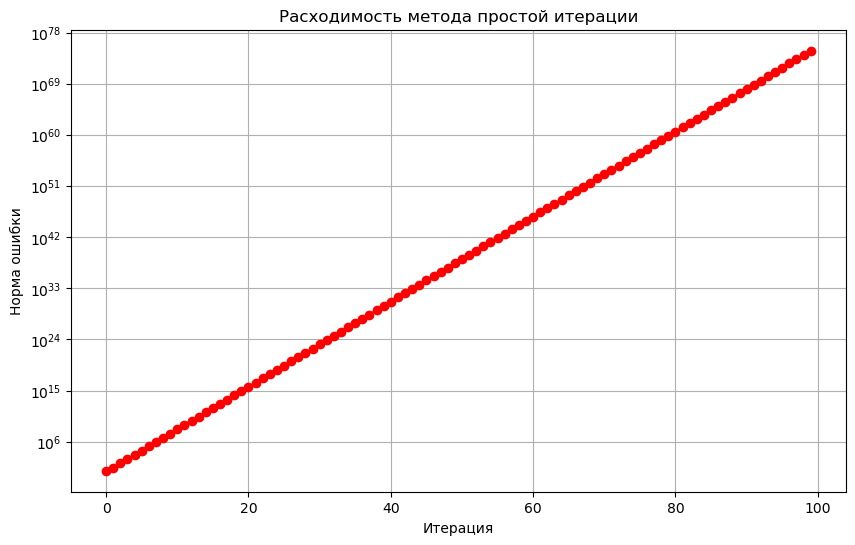

In [43]:
plt.figure(figsize=(10,6))
plt.semilogy(residuals_bad, marker='o', color='red')
plt.xlabel("Итерация")
plt.ylabel("Норма ошибки")
plt.title("Расходимость метода простой итерации")
plt.grid(True)
plt.show()